In [2]:
def summarize_classification(y_test, y_pred):
    acc = accuracy_score(y_test, y_pred, normalize=True)
    prec = precision_score(y_test, y_pred,pos_label=0)
    recall = recall_score(y_test, y_pred,pos_label=0)
    f1 = f1_score(y_test, y_pred,pos_label=0)
    roc = roc_auc_score(y_test, y_pred)
    cantidadNoPagoAtiempo = np.count_nonzero(y_pred == 0)

    

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": recall,
        "f1_score": f1,
        "roc_auc": roc,
        "casosNoPagoAtiempo": cantidadNoPagoAtiempo
    }

In [3]:
def build_model(
    classifier_fn,
    data_params: dict,
    test_frac: float = 0.2,
) -> dict:
    """
    Function to train a classification model

    Args:
        classifier_fn: classification function
        preprocessor (ColumnTransformer): preprocessor pipeline object
        data_params (dict): dictionary containing 'name_of_y_col',
                            'names_of_x_cols', and 'dataset'
        test_frac (float): fraction of data for the test, default 0.2

    Returns:
        dict: dictionary with the model performance metrics on train and test

    """

    # Extract data parameters
    name_of_y_col = data_params["name_of_y_col"]
    names_of_x_cols = data_params["names_of_x_cols"]
    dataset = data_params["dataset"]

    # Separate the feature columns and the target column
    X = dataset[names_of_x_cols]
    Y = dataset[name_of_y_col]

    # Split the data into train and test
    x_train, x_test, y_train, y_test = train_test_split(
        X, Y, test_size=test_frac, random_state=1234
    )

    # Create the pipeline with preprocessing and the classification model
    classifier_pipe = Pipeline(
        steps=[("model", classifier_fn)]
    )

    # Train the classifier pipeline
    model = classifier_pipe.fit(x_train, y_train)

    # Predict the test data
    y_pred = model.predict(x_test)

    # Predict the train data
    y_pred_train = model.predict(x_train)

    # Calculate the performance metrics
    train_summary = summarize_classification(y_train, y_pred_train)
    test_summary = summarize_classification(y_test, y_pred)

    kfold = KFold(n_splits=10)
    model_pipe = Pipeline(steps=[("model", model)])

    cv_results = {}
    train_results = {}

    # Ejecutamos validación cruzada
    for metric in scoring_metrics[:-1]:  
        cv_results[metric] = cross_val_score(
            model_pipe, x_train, y_train, cv=kfold, scoring=metric
        )
        # Se evalúa sobre el Dataset de pruebas
        model_pipe.fit(x_train, y_train)
        train_results[metric] = model_pipe.score(x_train, y_train)

    # Se convierten los resultados en un df
    cv_results_df = pd.DataFrame(cv_results)

    common_params = {
        "X": x_train,
        "y": y_train,
        "train_sizes": np.linspace(0.1, 1.0, 5),
        "cv": ShuffleSplit(n_splits=50, test_size=0.2, random_state=123),
        "n_jobs": -1,
        "return_times": True,
    }

    scoring_metric = "recall"

    train_sizes, train_scores, test_scores, fit_times, score_times = learning_curve(
        model_pipe, **common_params, scoring=scoring_metric
    )

    # Calculate the mean and standard deviation of the scores
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    # Calculate the mean and standard deviation of the fit and score times
    fit_times_mean = np.mean(fit_times, axis=1)
    fit_times_std = np.std(fit_times, axis=1)
    score_times_mean = np.mean(score_times, axis=1)
    score_times_std = np.std(score_times, axis=1)

    # Plot the learning curve
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 6), sharey=True)
    ax.plot(train_sizes, train_mean, "o-", label="Training score")
    ax.plot(train_sizes, test_mean, "o-", color="orange", label="Cross-validation score")
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.3)
    ax.fill_between(
        train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.3, color="orange"
    )

    # Configure the title and labels
    ax.set_title(f"Learning Curve for {model.steps[-1][1].__class__.__name__}")
    ax.set_xlabel("Training examples")
    ax.set_ylabel(scoring_metric)
    ax.legend(loc="best")

    # Show the plot
    plt.show()

    # Print the values for analysis
    print("Training Sizes:", train_sizes)
    print("Training Scores Mean:", train_mean)
    print("Training Scores Std:", train_std)
    print("Test Scores Mean:", test_mean)
    print("Test Scores Std:", test_std)

        # Plot the scalability regarding fit time and score time
    fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 12), sharex=True)

    # Scalability regarding the fit time
    ax[0].plot(train_sizes, fit_times_mean, "o-")
    ax[0].fill_between(
        train_sizes,
        fit_times_mean - fit_times_std,
        fit_times_mean + fit_times_std,
        alpha=0.3,
    )
    ax[0].set_ylabel("Fit time (s)")
    ax[0].set_title(f"Scalability of the {model.steps[-1][1].__class__.__name__} classifier")

    # Scalability regarding the score time
    ax[1].plot(train_sizes, score_times_mean, "o-")
    ax[1].fill_between(
        train_sizes,
        score_times_mean - score_times_std,
        score_times_mean + score_times_std,
        alpha=0.3,
    )
    ax[1].set_ylabel("Score time (s)")
    ax[1].set_xlabel("Number of training samples")

    # Show the plot
    plt.show()

    # Print the fit and score times for analysis
    print("Fit Times Mean:", fit_times_mean)
    print("Fit Times Std:", fit_times_std)
    print("Score Times Mean:", score_times_mean)
    print("Score Times Std:", score_times_std)

    return {"train": train_summary, "test": test_summary}

In [4]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import RadiusNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

In [5]:
y = 'Pago_atiempo'
features = df.columns[df.columns != y].tolist()

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10581 entries, 1 to 10762
Data columns (total 18 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   bin_encoder__tipo_laboral                 10581 non-null  float64
 1   poly_ohe__tipo_credito_9                  10581 non-null  float64
 2   poly_ohe__tipo_credito_10                 10581 non-null  float64
 3   poly_ohe__tendencia_ingresos_Decreciente  10581 non-null  float64
 4   poly_ohe__tendencia_ingresos_Estable      10581 non-null  float64
 5   capital_prestado                          10581 non-null  float64
 6   plazo_meses                               10581 non-null  float64
 7   edad_cliente                              10581 non-null  float64
 8   salario_cliente                           10581 non-null  float64
 9   total_otros_prestamos                     10581 non-null  float64
 10  puntaje_datacredito                    

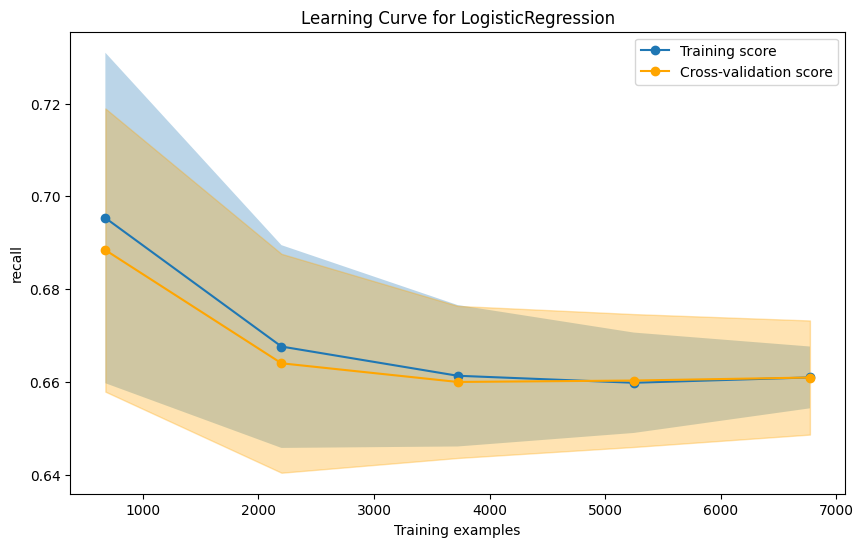

Training Sizes: [ 677 2200 3724 5247 6771]
Training Scores Mean: [0.69533891 0.66762246 0.6613224  0.65981279 0.66096452]
Training Scores Std: [0.03562547 0.02185693 0.01524349 0.01082191 0.0066627 ]
Test Scores Mean: [0.68841648 0.66401115 0.6599877  0.66029187 0.66094122]
Test Scores Std: [0.03052389 0.0235923  0.01639429 0.01432519 0.01229923]


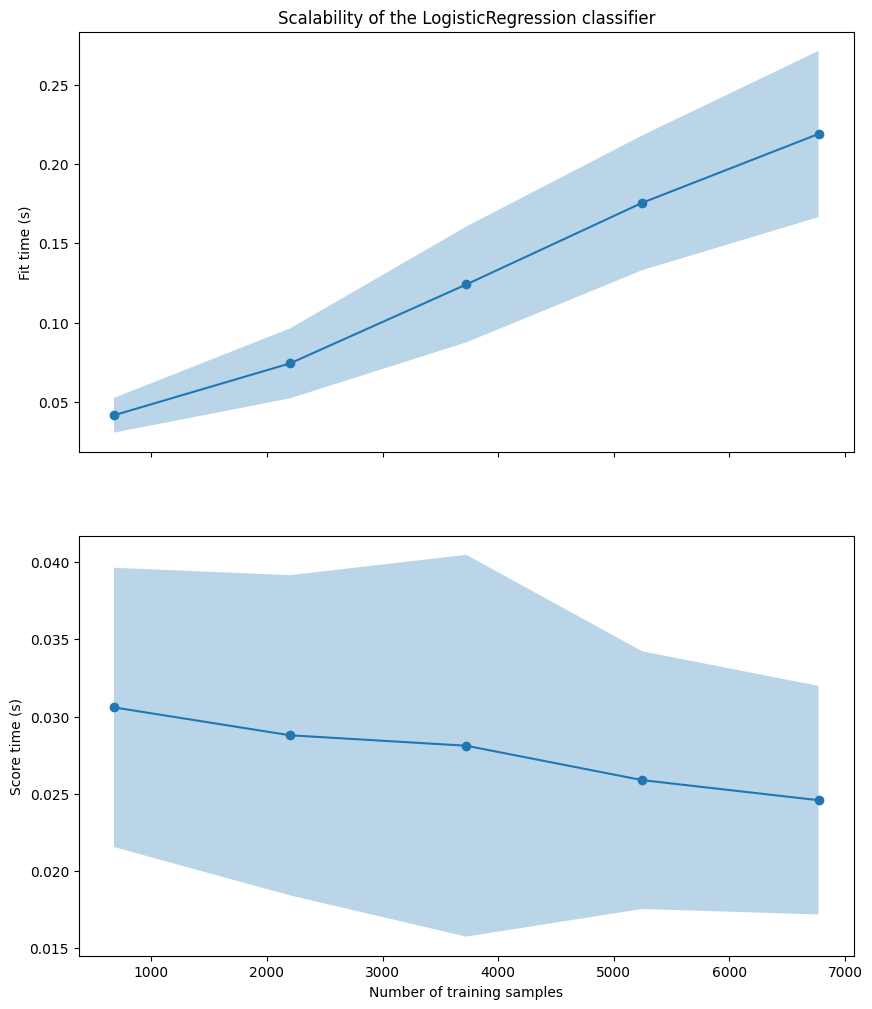

Fit Times Mean: [0.04155498 0.07425058 0.12397779 0.1754961  0.2188476 ]
Fit Times Std: [0.01095837 0.02205207 0.03651226 0.04248634 0.05240194]
Score Times Mean: [0.03058997 0.02878446 0.02810844 0.02587936 0.0245814 ]
Score Times Std: [0.00904286 0.0103689  0.01236128 0.00834093 0.00740101]


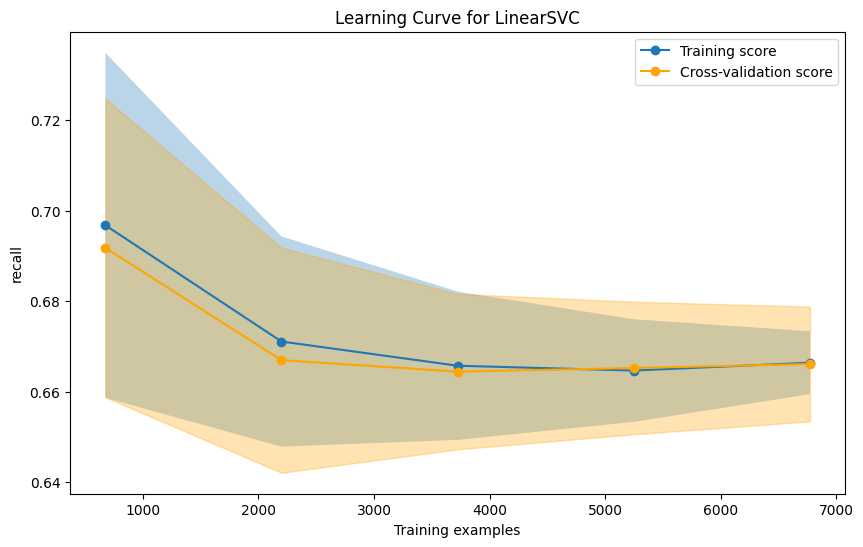

Training Sizes: [ 677 2200 3724 5247 6771]
Training Scores Mean: [0.69678345 0.67109367 0.6657403  0.66467699 0.66641437]
Training Scores Std: [0.03812722 0.02322916 0.01638199 0.01134124 0.00695099]
Test Scores Mean: [0.69178401 0.66697023 0.66444098 0.66524038 0.66612332]
Test Scores Std: [0.03300513 0.02487058 0.01717553 0.01463819 0.01267804]


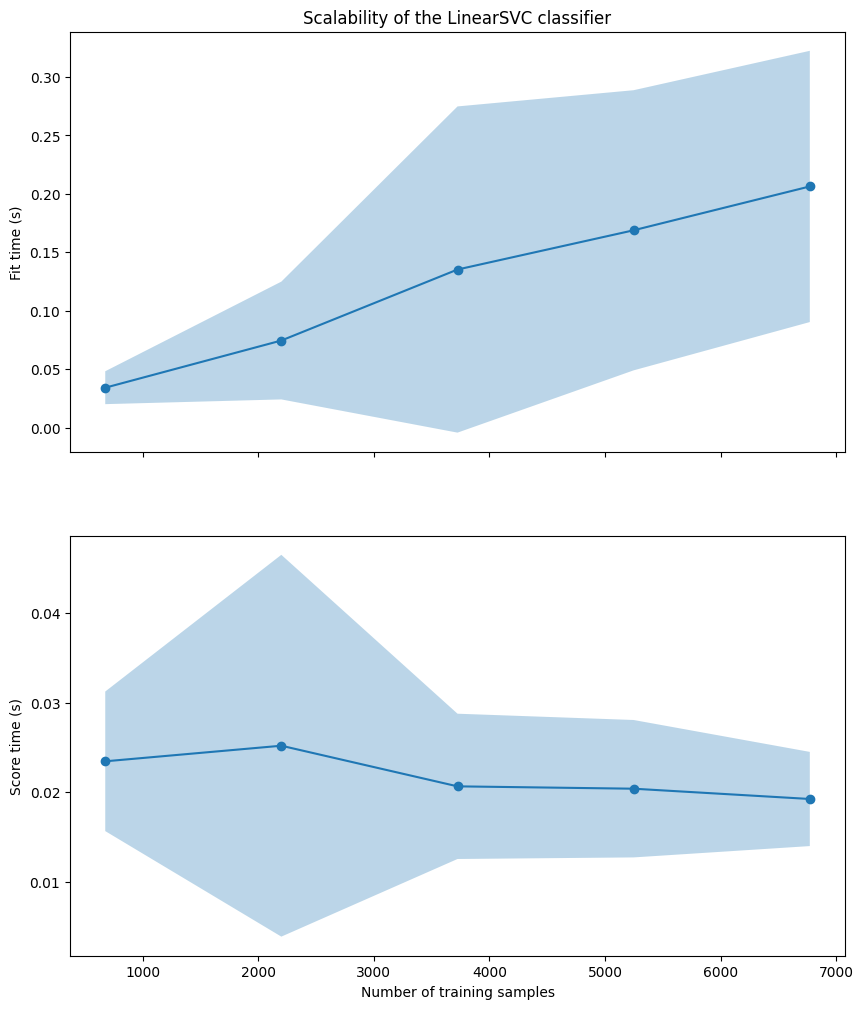

Fit Times Mean: [0.03419275 0.07456111 0.13531128 0.16888715 0.20641065]
Fit Times Std: [0.01407342 0.05039126 0.13956406 0.11986092 0.11604814]
Score Times Mean: [0.02345274 0.02519012 0.02066033 0.02039787 0.01925166]
Score Times Std: [0.00778144 0.02128585 0.00809945 0.0076613  0.00525079]


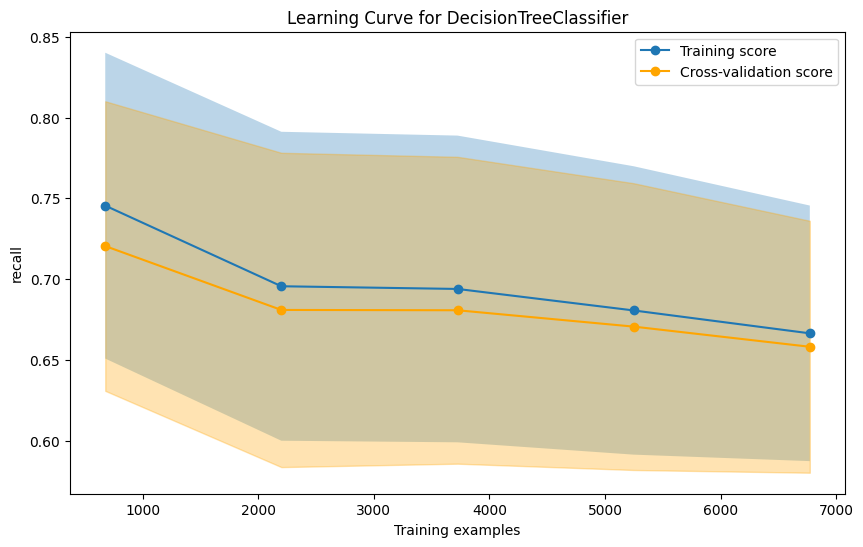

Training Sizes: [ 677 2200 3724 5247 6771]
Training Scores Mean: [0.74549583 0.69558771 0.69391997 0.68061826 0.66644584]
Training Scores Std: [0.09466802 0.0956343  0.09494192 0.08927102 0.07911228]
Test Scores Mean: [0.72046736 0.68091913 0.68072623 0.67060697 0.65812352]
Test Scores Std: [0.08963475 0.09728658 0.09498496 0.08876477 0.07797458]


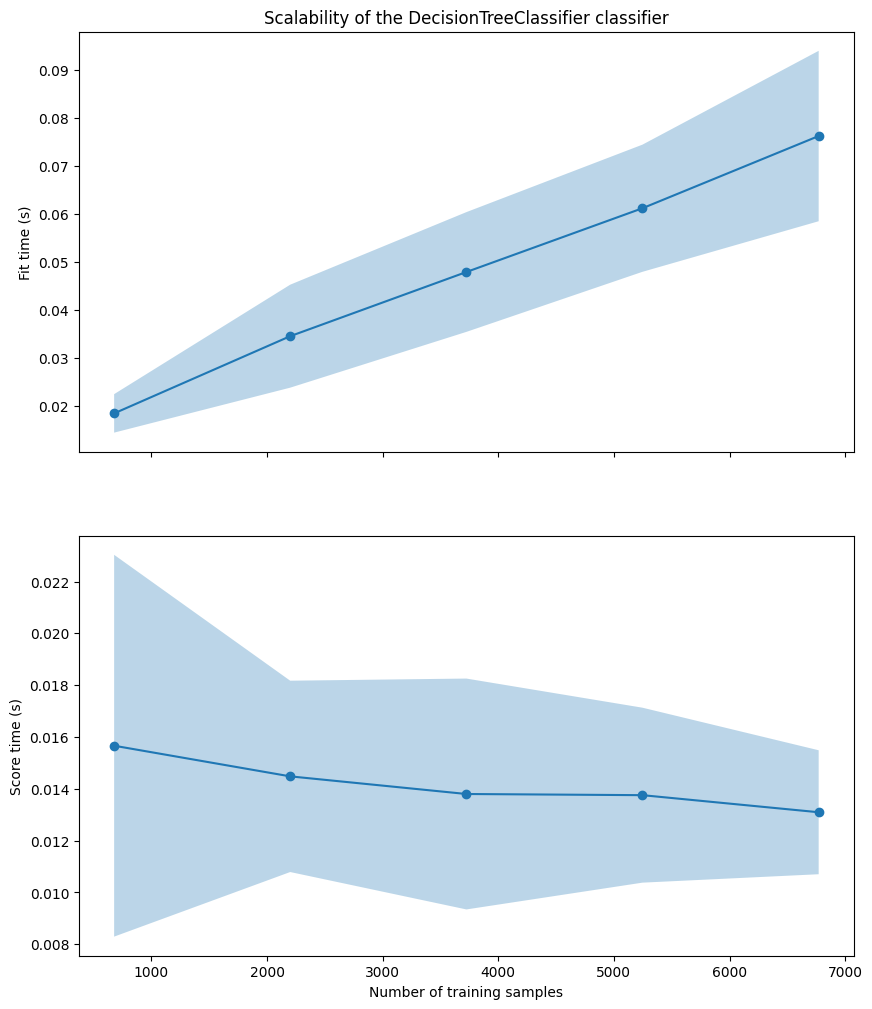

Fit Times Mean: [0.01840359 0.0345146  0.04790508 0.06121179 0.07627721]
Fit Times Std: [0.00401453 0.01074445 0.01249495 0.01326776 0.01777934]
Score Times Mean: [0.0156643  0.01448183 0.01380111 0.01375593 0.01309695]
Score Times Std: [0.0073677  0.00369204 0.00445499 0.00337596 0.0023922 ]


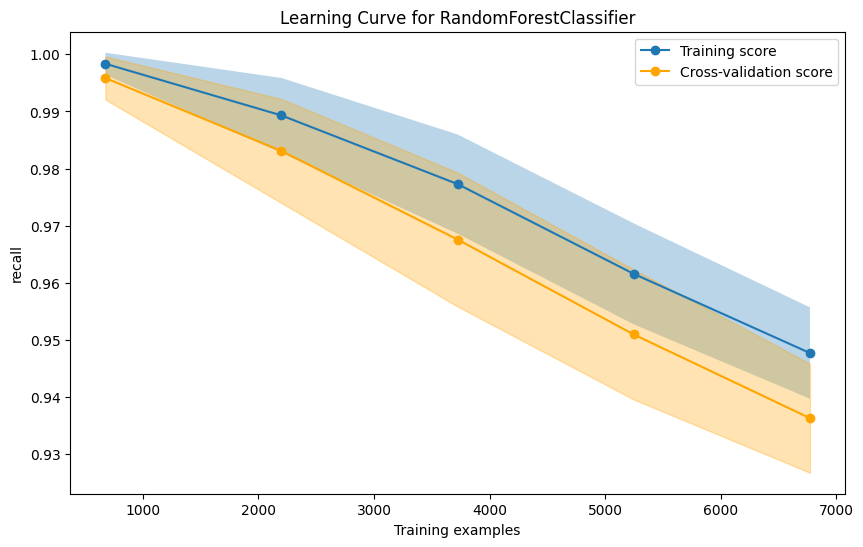

Training Sizes: [ 677 2200 3724 5247 6771]
Training Scores Mean: [0.998354   0.98930991 0.97729105 0.96158196 0.94772671]
Training Scores Std: [0.00192913 0.00655642 0.00868489 0.00883395 0.00799438]
Test Scores Mean: [0.99585757 0.98308087 0.96758414 0.95097417 0.9363257 ]
Test Scores Std: [0.00376894 0.00910089 0.01172681 0.01137961 0.00954824]


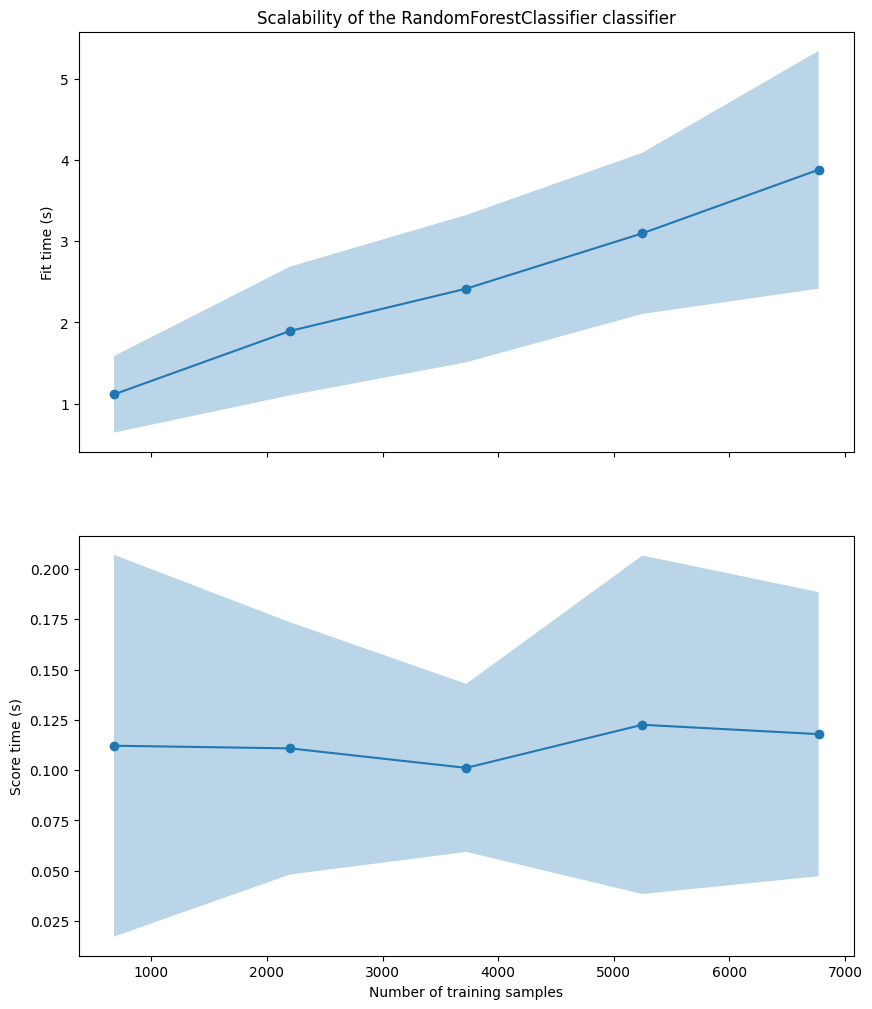

Fit Times Mean: [1.11465721 1.89555464 2.41706008 3.09850399 3.88196335]
Fit Times Std: [0.47168186 0.79320117 0.90776229 0.99311003 1.46547386]
Score Times Mean: [0.1121769  0.11085712 0.10116252 0.12260135 0.11793656]
Score Times Std: [0.09492004 0.06271689 0.04178785 0.0841561  0.07063933]


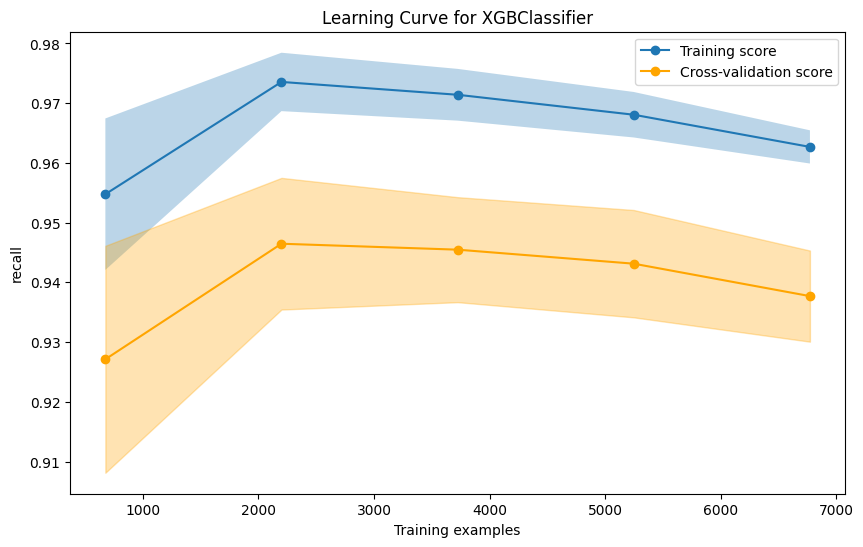

Training Sizes: [ 677 2200 3724 5247 6771]
Training Scores Mean: [0.95476107 0.97355142 0.97140256 0.96806247 0.96267394]
Training Scores Std: [0.01267683 0.00488943 0.00433263 0.0038087  0.00277973]
Test Scores Mean: [0.92712473 0.94646721 0.94547294 0.94312664 0.93769796]
Test Scores Std: [0.01899126 0.01102069 0.00878853 0.00898363 0.00762619]


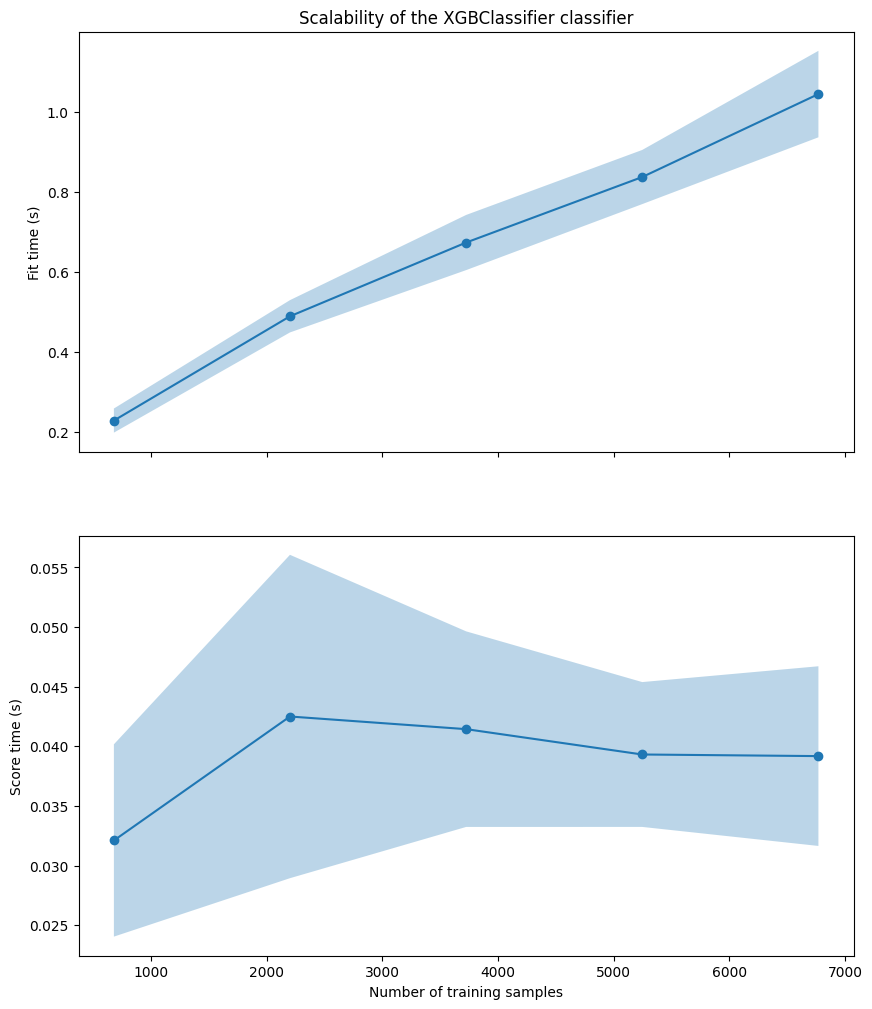

Fit Times Mean: [0.22798935 0.48862462 0.67297419 0.8366589  1.04402404]
Fit Times Std: [0.03011942 0.04036055 0.06893506 0.06767663 0.1080858 ]
Score Times Mean: [0.03210753 0.04250152 0.04144166 0.03931643 0.03918143]
Score Times Std: [0.00806073 0.01355569 0.00819831 0.00607188 0.00753239]


In [7]:
result_dict = {}
models = {
    "logistic": LogisticRegression(solver="liblinear",class_weight='balanced'),
    # class_weight='balanced' para manejar clases desbalanceadas
    "svc": LinearSVC(C=1.0, max_iter=1000, tol=1e-3, dual=False,class_weight='balanced'),
    "decision_tree": DecisionTreeClassifier(max_depth=5,min_samples_leaf=10,class_weight='balanced'),
    "random_forest": RandomForestClassifier(class_weight='balanced',n_estimators=150,max_depth=7,min_samples_leaf=5,max_features='sqrt'),
    "xgboost": XGBClassifier(eval_metric='logloss',scale_pos_weight=491 / 10090,n_estimators=200,max_depth=6,learning_rate=0.1,subsample=0.8,colsample_bytree=0.8)
    
}

data_params = {
    "name_of_y_col": y,
    "names_of_x_cols": features,
    "dataset": df
}
for model_name, model in models.items():
    result_dict[model_name] = build_model(model, data_params)

In [8]:
records = []
for model_name, model_results in result_dict.items():
    for data_set, metrics in model_results.items():
        for metric_name, score in metrics.items():
            records.append({
                "Model": model_name,
                "Data Set": data_set,
                "Metric": metric_name,
                "Score": score
            })

results_df = pd.DataFrame(records)

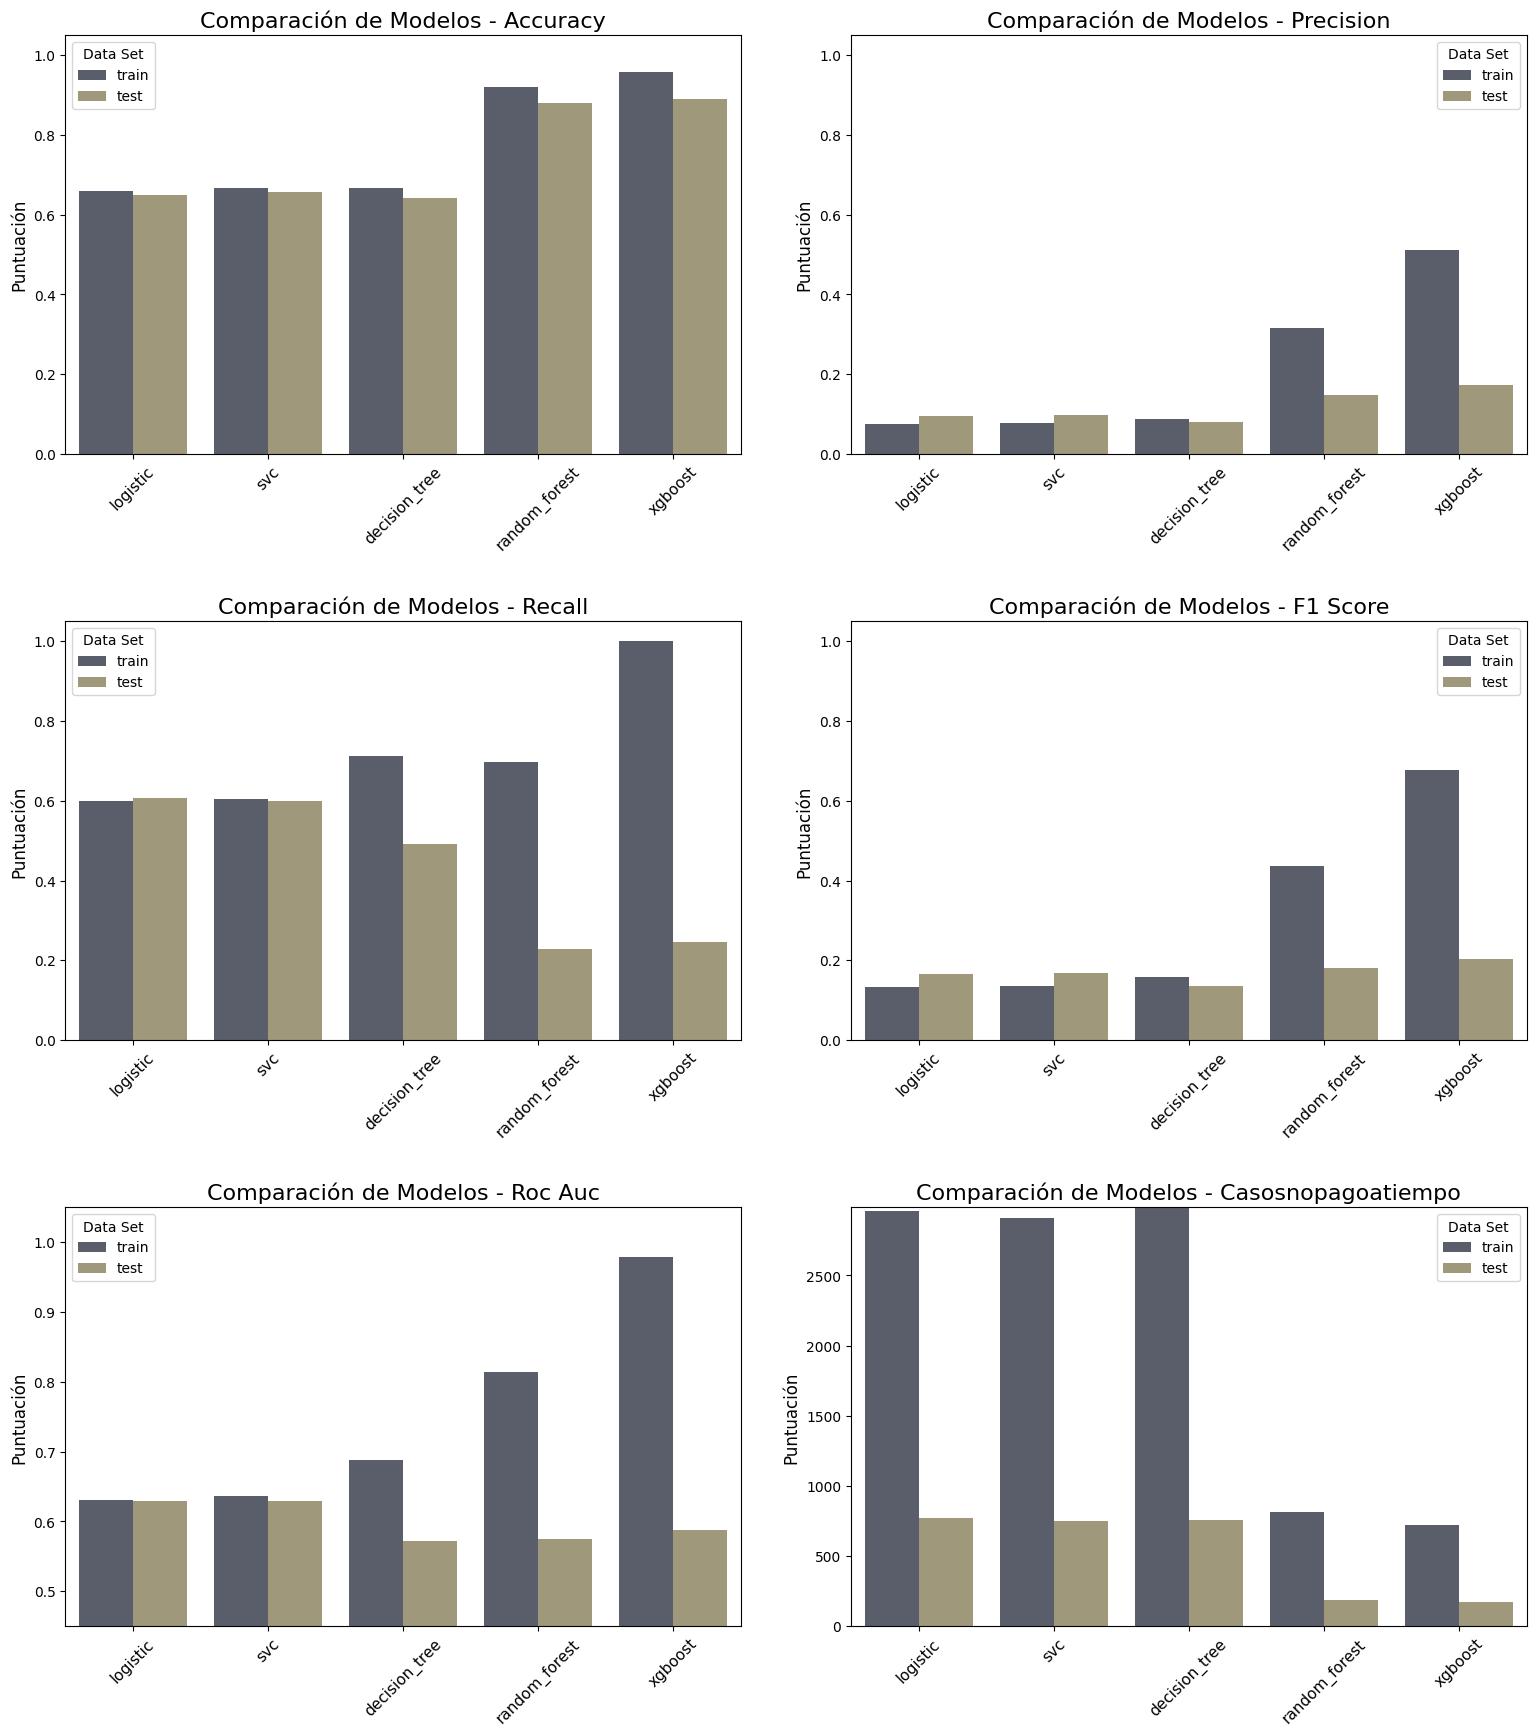

In [9]:


# Crear una figura con una cuadrícula de subplots (3 filas, 2 columnas)
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten() # Aplanar la matriz de ejes para iterar fácilmente

# Iterar sobre cada métrica y crear un gráfico para ella
for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    # Filtrar el DataFrame para la métrica actual
    metric_df = results_df[results_df["Metric"] == metric]
    
    # Crear el gráfico de barras agrupado
    sns.barplot(data=metric_df, x="Model", y="Score", hue="Data Set", ax=ax, palette="cividis")
    
    ax.set_title(f'Comparación de Modelos - {metric.replace("_", " ").title()}', fontsize=16)
    ax.set_ylabel("Puntuación", fontsize=12)
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=45, labelsize=11)
    
    # Ajustar el límite del eje Y para que la comparación sea justa
    # Para ROC AUC, la escala es de 0.45 a 1.05 para ver mejor las diferencias
    if metric == 'roc_auc':
        ax.set_ylim(0.45, 1.05)
    elif metric == 'casosNoPagoAtiempo':
        max_no_pago = results_df[results_df["Metric"] == "casosNoPagoAtiempo"]["Score"].max()
        ax.set_ylim(0, max_no_pago + 5)
    else:
        ax.set_ylim(0, 1.05)

# Ocultar el último subplot que no se usa
if len(metrics_to_plot) < len(axes):
    axes[-1].set_visible(False)

# Ajustar el diseño para que no se superpongan los títulos
plt.tight_layout(pad=3.0)
plt.show()

El modelo XGBoost será  usado porque ofrece las mejores métricas de precisión, F1-Score y ROC AUC, lo que garantiza predicciones de alta calidad. Además, muestra un sobreajuste mucho más controlado que otros modelos complejos como Random Forest, lo que lo hace más fiable en un entorno de producción. Adicionalmente, es significativamente más rápido de entrenar que Random Forest, lo que permite un desarrollo más ágil y su aplicación a conjuntos de datos más grandes sin problemas. Como xgboost no es sensible al escalado de datos, se entrenará con los datos originales del dataframe

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10581 entries, 1 to 10762
Data columns (total 18 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   bin_encoder_tipo_laboral                 10581 non-null  float64
 1   poly_ohe_tipo_credito_9                  10581 non-null  float64
 2   poly_ohe_tipo_credito_10                 10581 non-null  float64
 3   poly_ohe_tendencia_ingresos_Decreciente  10581 non-null  float64
 4   poly_ohe_tendencia_ingresos_Estable      10581 non-null  float64
 5   capital_prestado                         10581 non-null  float64
 6   plazo_meses                              10581 non-null  float64
 7   edad_cliente                             10581 non-null  float64
 8   salario_cliente                          10581 non-null  float64
 9   total_otros_prestamos                    10581 non-null  float64
 10  puntaje_datacredito                      10581 non-